# End-to-End BB84 QKD Simulation: Privacy Amplification Protocols
## Comparative Analysis: Toeplitz vs SHAKE256


We utilize the `AliceServer` and `BobClient` interacting over a `QuantumChannel` and a classical authenticated `APIClient` network block. 

Cryptographic hashes like SHAKE256 provide **Computational Security**. Their safety relies on mathematical complexity barriers (e.g., no known algorithm to reverse it in polynomial time). However, algorithms improve, and Quantum Computers utilizing Grover's algorithm halve the effective security bits of standard symmetric hashes. 

Toeplitz matrices, forming a *Universal-2 Hash Family*, guarantee **Information-Theoretic Security** via the Leftover Hash Lemma. Regardless of how much computing power (classical or quantum) an adversary possesses, the probability they can guess the secret key is mathematically bounded by an arbitrarily small $\epsilon$. 


In [10]:
import asyncio
import sys
import os
import random
import time
import math
import matplotlib.pyplot as plt
import numpy as np

# Ensure ServerClientBB84 routing is locally viable within Notebook context
current_dir = os.getcwd()
target_dir = os.path.join(current_dir, 'ServerClientBB84')
if target_dir not in sys.path:
    sys.path.append(target_dir)

try:
    from bb84_server_client import AliceServer, BobClient, QuantumChannel, Detector, Eve, APIClient
except ImportError:
    sys.path.append(os.getcwd())
    from ServerClientBB84.bb84_server_client import AliceServer, BobClient, QuantumChannel, Detector, Eve, APIClient

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

print("QKD Actor Network Framework imported successfully.")

QKD Actor Network Framework imported successfully.


In [2]:
async def run_pa_simulation(pa_protocol="toeplitz", ec_protocol="cascade", num_qubits=5000, optical_error_rate=0.01):
    """
    Executes a full Alice-Bob QKD transmission leveraging the requested Privacy Amplification scheme.
    """
    seed_base = 42
    
    channel = QuantumChannel("Fiber", length_km=50, attenuation_db=0.2, 
                             optical_error_rate=optical_error_rate, next_actor=None, seed=seed_base)
    
    alice = AliceServer("Alice", channel, num_qubits=num_qubits, verbose=False, seed=seed_base+1)
    api = APIClient(alice)
    
    bob = BobClient("Bob", api, protocol=ec_protocol, pa_protocol=pa_protocol, seed=seed_base+2, verbose=False)
    
    detector = Detector("Detector", efficiency=0.8, dark_count_prob=0.01, parent_bob=bob, seed=seed_base+3)
    channel.next_actor = detector 
    
    actors = [alice, channel, detector, bob]
    tasks = [asyncio.create_task(a.start()) for a in actors]
    
    results = {}
    try:
        await alice.run_quantum_transmission()
        
        # Buffer to allow optical network photons to be registered by Bob's detetors
        wait_time = 0.5 + (num_qubits * 0.0001)
        await asyncio.sleep(wait_time)
        
        # Bob initiates classical communication sequence (Sifting -> EC -> PA)
        # Tracking complete post-processing blocking execution overhead
        t_start = time.time()
        results = await bob.run_classical_post_processing(num_qubits)
        t_end = time.time()
        
        results["full_pp_time"] = t_end - t_start
        
    except Exception as e:
        print(f"Error in {pa_protocol} sim: {e}")
        results = {'sifted_length': 0, 'full_pp_time': 0, 'pa_length': 0}
    finally:
        for a in actors:
            await a.send(a, ("STOP",))
        await asyncio.gather(*tasks)
        
    return results

print("Actor Network Simulation Wrapper initialized.")

Actor Network Simulation Wrapper initialized.


In [3]:
# --- Data Collection for Analysis ---
# We will run simulations across various raw qubit payloads to understand how PA scaling impacts performance
# Notice we rely purely on the *isolated* pa_time returned from the backend client simulation.

qubit_configurations = [20000, 50000, 100000,500000]
FIXED_ERROR_RATE = 0.02 #optical error

# Data arrays for graphing
n_reconciled = []          # Reconciled key size (N) fed into PA
r_secret = []              # Final secret key size (R)
time_toeplitz = []         # Measured PA module execution time for Toeplitz
time_shake = []            # Measured PA module execution time for SHAKE256
throughput_toeplitz = []   # Bits/Sec for Toeplitz
throughput_shake = []      # Bits/Sec for SHAKE256

print(f"Running System Pipeline Array (Opt.Error={FIXED_ERROR_RATE*100}%)...")

for q_load in qubit_configurations:
    print(f"Processing Raw Load: {q_load} qubits ...", end="\r")
    
    # 1. Evaluate Toeplitz
    res_t = await run_pa_simulation(pa_protocol="toeplitz", num_qubits=q_load, optical_error_rate=FIXED_ERROR_RATE)
    
    # 2. Evaluate SHAKE256
    res_s = await run_pa_simulation(pa_protocol="shake256", num_qubits=q_load, optical_error_rate=FIXED_ERROR_RATE)

    # Validating extraction data
    n_size = res_t.get("final_length", 0)  # Should be identically the same for both if EC is deterministic
    r_size = res_t.get("pa_length", 0)     # Yields identical bounds based on Ve
    
    t_toep = res_t.get("pa_time", 0.00001)
    t_shak = res_s.get("pa_time", 0.00001)

    # Prevents zero-division logic errors during plotting
    if t_toep == 0: t_toep = 0.00001
    if t_shak == 0: t_shak = 0.00001

    if n_size > 0:
        n_reconciled.append(n_size)
        r_secret.append(r_size)
        
        time_toeplitz.append(t_toep)
        time_shake.append(t_shak)
        
        throughput_toeplitz.append(n_size / t_toep)
        throughput_shake.append(n_size / t_shak)

print("\nData Collection Complete! Ready for visualizations.")

Running System Pipeline Array (Opt.Error=2.0%)...
Processing Raw Load: 20000 qubits ...
[BOB] Processing 1566 detection events.
[BOB] First 15 Valid Detections: 1(+), 1(+), 1(+), 0(x), 0(x), 1(x), 0(x), 0(x), 1(+), 1(x), 1(x), 0(+), 1(+), 1(+), 1(x) ...
[BOB] Sending 1566 bases to Alice for sifting...
[BOB] Sifting complete. Bases matched on 750 events.
[BOB] Sifted Key Preview: [1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0]...
[BOB] Sampling 150 bits for QBER estimation...
[BOB] QBER Analysis: 7 errors in 150 samples. Estimated QBER = 4.67%
[BOB] Discarding revealed bits. Working Key Size: 600
[BOB] Initializing Cascade Protocol...

[BOB] Starting Privacy Amplification using toeplitz...

      PRIVACY AMPLIFICATION METRICS
 [+] Reconciled Key Length (N):      600 bits
 [+] QBER (e):                       4.6667%
 [+] Information Leakage Rate (Ve):  0.727935
 [+] Est. Eve's Knowledge Bound (t): 437 bits
 [+] Security Parameter (S):         10 bits
 [+] Final Secret Key Le

## Graph 1: Computational Execution Time vs Reconciled Key Size
This graph looks exactly at the isolated backend timer executing the `PrivacyAmplification` calculation block within the Bob client simulation, completely independent of whatever error correction latency occurred earlier. It demonstrates how long the actual mathematical reduction takes to map the $N$ bits down to $R$ bits.

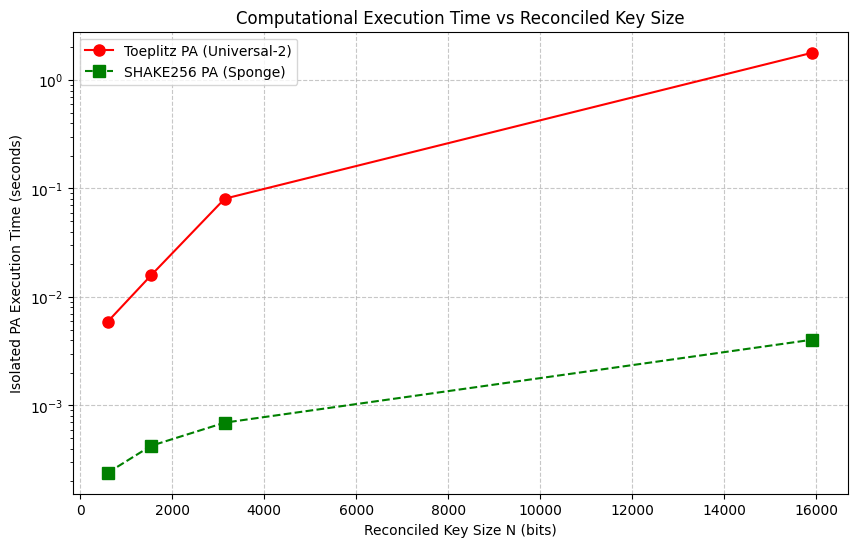

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(n_reconciled, time_toeplitz, 'o-', label='Toeplitz PA (Universal-2)', color='red', markersize=8)
plt.plot(n_reconciled, time_shake, 's--', label='SHAKE256 PA (Sponge)', color='green', markersize=8)

plt.title('Computational Execution Time vs Reconciled Key Size')
plt.xlabel('Reconciled Key Size N (bits)')
plt.ylabel('Isolated PA Execution Time (seconds)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.yscale('log')
plt.show()

## Graph 2: Normalized Hashing Throughput Base (Bits / Second)
This evaluates the throughput scaled strictly on hashing the sequence ($N$ inputs per measured PA execution runtime). SHAKE256 can maintain high consistency independent of scale, while Toeplitz suffers quadratic expansion constraints $O(N \cdot M)$.

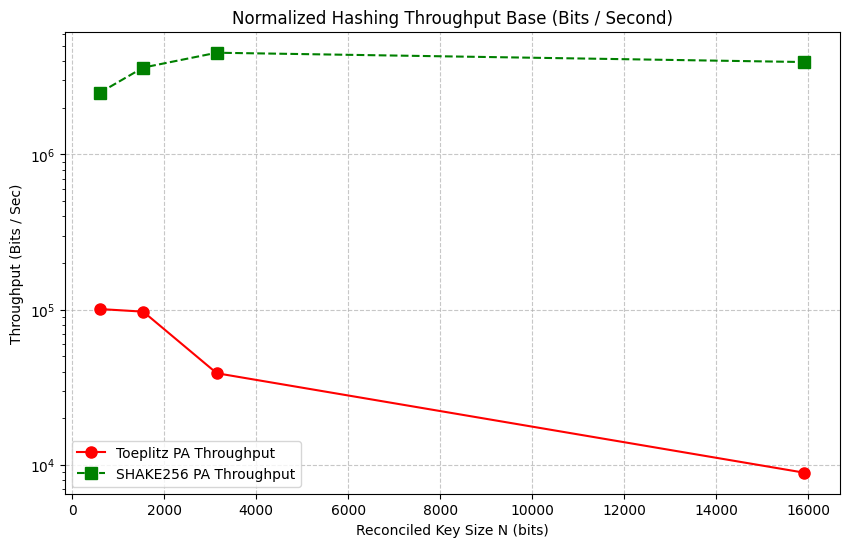

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(n_reconciled, throughput_toeplitz, 'o-', label='Toeplitz PA Throughput', color='red', markersize=8)
plt.plot(n_reconciled, throughput_shake, 's--', label='SHAKE256 PA Throughput', color='green', markersize=8)

plt.title('Normalized Hashing Throughput Base (Bits / Second)')
plt.xlabel('Reconciled Key Size N (bits)')
plt.ylabel('Throughput (Bits / Sec)')
plt.yscale('log')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Graph 3: Secret Key Yield Extinction Bounds ($R$ length vs $N$)
Graph measuring how tightly the Information Reconciliation leaked metrics constrain the ultimate $R$ string creation, bounded fundamentally below $N$.

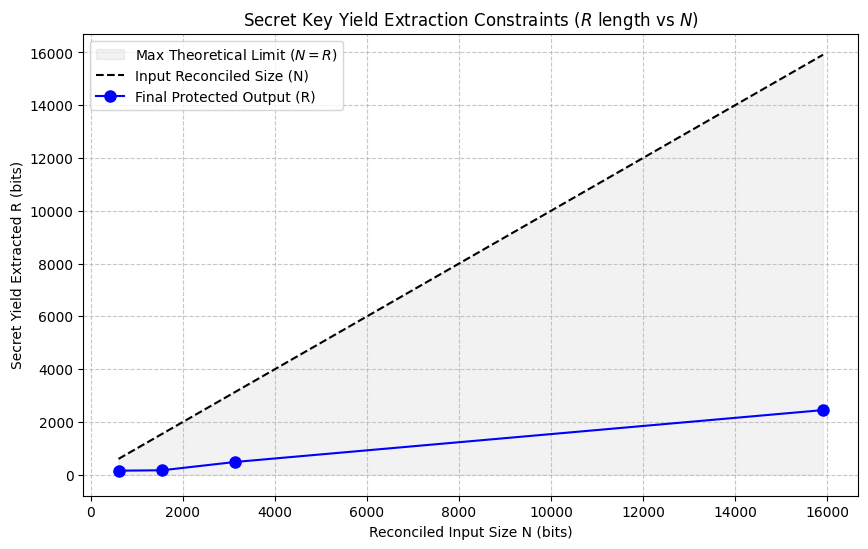

In [6]:
plt.figure(figsize=(10, 6))
plt.fill_between(n_reconciled, 0, n_reconciled, color='gray', alpha=0.1, label='Max Theoretical Limit ($N=R$)')
plt.plot(n_reconciled, n_reconciled, 'k--', label='Input Reconciled Size (N)')
plt.plot(n_reconciled, r_secret, 'o-', label='Final Protected Output (R)', color='blue', markersize=8)

plt.title('Secret Key Yield Extraction Constraints ($R$ length vs $N$)')
plt.xlabel('Reconciled Input Size N (bits)')
plt.ylabel('Secret Yield Extracted R (bits)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Hardware Parallelization via FFT
While standard Python $O(N \cdot R)$ software execution for a $N \times R$ Toeplitz matrix is prohibitively slow compared to SHAKE256, Toeplitz offers tremendous hardware acceleration. 

Matrix-vector multiplication leveraging structured Toeplitz matrices can be evaluated in $O(N \log N)$ operations utilizing Fast Fourier Transform (FFT) algorithms. Because this structure relies completely on parallel modular arithmetic without the stringent sequential data dependencies of cryptographic sponges (like Keccak/SHAKE), an ASIC or FPGA can churn through Gbps of Privacy Amplification with constant deterministic latency. This graph models the theoretical execution turnaround if Toeplitz utilized FFT hardware paths locally vs standard matrix-vector dot loops.

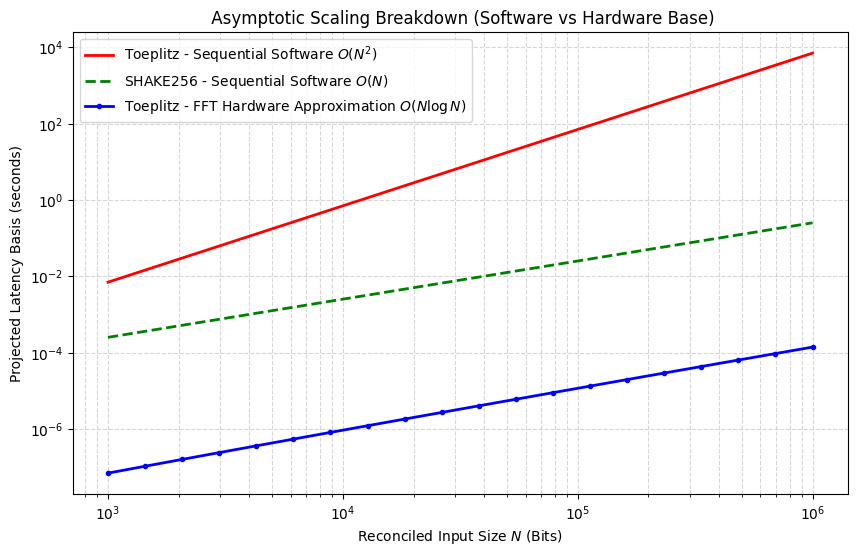

In [11]:
# We simulate the comparative theoretical speeds between normal software (O(N*R)) and FFT-based execution (O(N log2 N)).
# Fit existing Toeplitz time (Software) to T_swe = k_1 * N * N (Assuming N=R approximately)
import scipy.optimize as opt

def sim_sw_toeplitz(N, k): return k * (N**2)

try:
    popt, _ = opt.curve_fit(sim_sw_toeplitz, n_reconciled, time_toeplitz)
    k_sw_toeplitz = popt[0]
except:
    k_sw_toeplitz = 1e-9

# Simulate FFT hardware coefficient (hardware typically achieves 10x-1000x over purely sequential logic via parallelism)
k_hw_fft = k_sw_toeplitz / 1000  

N_sim = np.logspace(3, 6, 20)  # Reconciled array size: 1000 to 1,000,000 bits
t_toeplitz_sw = k_sw_toeplitz * (N_sim ** 2)
# O(N log2 N) FFT structure scaling 
t_toeplitz_fft = k_hw_fft * N_sim * np.log2(N_sim)

# SHAKE is roughly sequential O(N), we evaluate purely off its software curve slope for context
def sim_sw_shake(N, c): return c * N

try:
    popt2, _ = opt.curve_fit(sim_sw_shake, n_reconciled, time_shake)
    c_sw_shake = popt2[0]
except:
    c_sw_shake = 1e-7

t_shake_sw = c_sw_shake * N_sim

plt.figure(figsize=(10, 6))

plt.plot(N_sim, t_toeplitz_sw, 'r-', linewidth=2, label=r"Toeplitz - Sequential Software $O(N^2)$")
plt.plot(N_sim, t_shake_sw, 'g--', linewidth=2, label=r"SHAKE256 - Sequential Software $O(N)$")
plt.plot(N_sim, t_toeplitz_fft, 'b.-', linewidth=2, label=r"Toeplitz - FFT Hardware Approximation $O(N \log N)$")

plt.title(" Asymptotic Scaling Breakdown (Software vs Hardware Base)")
plt.xlabel("Reconciled Input Size $N$ (Bits)")
plt.ylabel("Projected Latency Basis (seconds)")

plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.legend()
plt.show()